In [1]:
# Cell 1: Imports and Setup
import yfinance as yf
import pandas as pd
import numpy as np
from itertools import product
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

print("✅ Libraries imported successfully")
print(f"📅 Current date: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")


✅ Libraries imported successfully
📅 Current date: 2026-02-09 23:37:20


In [2]:
# Cell 2: Download ETH-USD data
END_DATE = '2025-12-31'  # Full year 2025 included

print(f"📊 Downloading ETH-USD data (2017 to {END_DATE})...")
data = yf.download('ETH-USD', start='2017-01-01', end=END_DATE, progress=False)

print(f"✅ Downloaded {len(data)} days of data")
print(f"   Date range: {data.index[0].date()} to {data.index[-1].date()}")
print(f"   Price range: ${float(data['Close'].min()):.2f} to ${float(data['Close'].max()):.2f}")

print("\n📋 First 5 rows of data:")
data.head()

📊 Downloading ETH-USD data (2017 to 2025-12-31)...
✅ Downloaded 2974 days of data
   Date range: 2017-11-09 to 2025-12-30
   Price range: $84.31 to $4831.35

📋 First 5 rows of data:


Price,Close,High,Low,Open,Volume
Ticker,ETH-USD,ETH-USD,ETH-USD,ETH-USD,ETH-USD
Date,,,,,
2017-11-09,320.884003,329.451996,307.056000,308.644989,893249984
2017-11-10,299.252991,324.717987,294.541992,320.670990,885985984
2017-11-11,314.681000,319.453003,298.191986,298.585999,842300992
2017-11-12,307.907990,319.153015,298.513000,314.690002,1613479936
2017-11-13,316.716003,328.415009,307.024994,307.024994,1041889984


In [3]:
# Cell 3: Import TA Library and Test ADX

from ta.trend import ADXIndicator

# yfinance returns multi-level columns, we need to flatten them
# Extract just the price columns as simple Series
high = data['High'].squeeze()  # Convert to 1D Series
low = data['Low'].squeeze()
close = data['Close'].squeeze()

print("📊 Data structure check:")
print(f"   High shape: {high.shape}")
print(f"   Low shape: {low.shape}")
print(f"   Close shape: {close.shape}")

# Test that it works with our data
test_adx = ADXIndicator(high=high, low=low, close=close, window=14)
adx_values = test_adx.adx()

print("\n✅ ADX library imported successfully")
print(f"   Calculated ADX for {len(adx_values)} days")
print(f"   ADX range: {float(adx_values.min()):.2f} to {float(adx_values.max()):.2f}")
print(f"   Current ADX: {float(adx_values.iloc[-1]):.2f}")
print("\n📊 Latest ADX values:")
print(adx_values.tail())

📊 Data structure check:
   High shape: (2974,)
   Low shape: (2974,)
   Close shape: (2974,)

✅ ADX library imported successfully
   Calculated ADX for 2974 days
   ADX range: 0.00 to 64.17
   Current ADX: 27.46

📊 Latest ADX values:
Date
2025-12-26    30.380663
2025-12-27    30.266162
2025-12-28    30.159840
2025-12-29    28.758281
2025-12-30    27.456833
Name: adx, dtype: float64


In [4]:
# Cell 4: Backtest Strategy Function (CORRECTED - Week 1 Logic)
def backtest_strategy(data, adx_threshold, adx_period):
    """
    Backtest ADX regime strategy with Week 1 logic
    
    RULES:
    - IF ADX < threshold: Position = 0 (Flat/Cash)
    - IF ADX >= threshold AND +DI > -DI: Position = 1 (Long)
    - IF ADX >= threshold AND -DI > +DI: Position = 0 (Flat)
    
    Parameters:
    -----------
    data : DataFrame
        OHLC price data
    adx_threshold : int
        Threshold for trending regime (e.g., 25)
    adx_period : int
        ADX calculation period (e.g., 14)
    
    Returns:
    --------
    dict : Performance metrics or None if backtest fails
    """
    
    df = data.copy()
    
    # Flatten columns if needed
    high = df['High'].squeeze()
    low = df['Low'].squeeze()
    close = df['Close'].squeeze()
    
    # Create clean dataframe
    df_clean = pd.DataFrame({
        'Close': close,
        'High': high,
        'Low': low
    }, index=df.index)
    
    # Calculate ADX and directional indicators
    adx_indicator = ADXIndicator(
        high=df_clean['High'], 
        low=df_clean['Low'], 
        close=df_clean['Close'], 
        window=adx_period
    )
    df_clean['ADX'] = adx_indicator.adx()
    df_clean['+DI'] = adx_indicator.adx_pos()
    df_clean['-DI'] = adx_indicator.adx_neg()
    
    # Regime detection
    df_clean['Regime_Trending'] = df_clean['ADX'] >= adx_threshold
    df_clean['Bullish'] = df_clean['+DI'] > df_clean['-DI']
    
    # Position logic (LONG ONLY)
    df_clean['Position'] = 0
    df_clean.loc[df_clean['Regime_Trending'] & df_clean['Bullish'], 'Position'] = 1
    
    # Calculate returns
    df_clean['Market_Return'] = df_clean['Close'].pct_change()
    df_clean['Strategy_Return'] = df_clean['Position'].shift(1) * df_clean['Market_Return']
    
    # Drop NaN values
    df_clean = df_clean.dropna()
    
    # Validate sufficient data
    if len(df_clean) < 100 or df_clean['Strategy_Return'].std() == 0:
        return None
    
    # Calculate performance metrics
    total_return = (1 + df_clean['Strategy_Return']).prod() - 1
    sharpe = df_clean['Strategy_Return'].mean() / df_clean['Strategy_Return'].std() * np.sqrt(365)
    
    # Calculate drawdown
    cumulative = (1 + df_clean['Strategy_Return']).cumprod()
    running_max = cumulative.expanding().max()
    drawdown = (cumulative - running_max) / running_max
    max_drawdown = drawdown.min()
    
    # Calmar ratio
    calmar = total_return / abs(max_drawdown) if max_drawdown != 0 else 0
    
    # Time in trending regime
    pct_trending = df_clean['Regime_Trending'].sum() / len(df_clean) * 100
    
    # Time long
    pct_long = (df_clean['Position'] == 1).sum() / len(df_clean) * 100
    
    return {
        'adx_threshold': adx_threshold,
        'adx_period': adx_period,
        'total_return': total_return,
        'sharpe_ratio': sharpe,
        'max_drawdown': max_drawdown,
        'calmar_ratio': calmar,
        'pct_trending': pct_trending,
        'pct_long': pct_long
    }

print("✅ Backtest function defined (CORRECTED - Week 1 long-only logic)")
print("   Rules: Long when ADX >= threshold AND +DI > -DI, else Flat")

✅ Backtest function defined (CORRECTED - Week 1 long-only logic)
   Rules: Long when ADX >= threshold AND +DI > -DI, else Flat


In [5]:
# Cell 5: Test backtest function with Week 1 parameters
print("🧪 Testing backtest with Week 1 parameters...")
print("   ADX Threshold: 25, ADX Period: 14")
print()

# Run backtest with Week 1 parameters
result = backtest_strategy(data, adx_threshold=25, adx_period=14)

if result:
    print("✅ Backtest successful!")
    print()
    print("📊 Week 1 Performance Baseline:")
    print(f"   Total Return:    {result['total_return']*100:>8.2f}%")
    print(f"   Sharpe Ratio:    {result['sharpe_ratio']:>8.3f}")
    print(f"   Max Drawdown:    {result['max_drawdown']*100:>8.2f}%")
    print(f"   Calmar Ratio:    {result['calmar_ratio']:>8.3f}")
    print(f"   % Time Trending: {result['pct_trending']:>8.2f}%")
    print(f"   % Time Long:     {result['pct_long']:>8.2f}%")
    print()
    print("🎯 This is your benchmark to beat with optimization!")
else:
    print("❌ Backtest failed - check function logic")



🧪 Testing backtest with Week 1 parameters...
   ADX Threshold: 25, ADX Period: 14

✅ Backtest successful!

📊 Week 1 Performance Baseline:
   Total Return:      953.11%
   Sharpe Ratio:       0.827
   Max Drawdown:      -51.75%
   Calmar Ratio:      18.416
   % Time Trending:    61.32%
   % Time Long:        28.39%

🎯 This is your benchmark to beat with optimization!


In [6]:
# Cell 6: Define parameter grid for optimization
print("🔬 Setting up grid search parameters...")
print()

# Parameters to test
adx_thresholds = [20, 22, 25, 27, 30, 32, 35]  # When is market "trending"?
adx_periods = [10, 14, 20, 25]                  # How sensitive is ADX calculation?

# Calculate total combinations
from itertools import product
combinations = list(product(adx_thresholds, adx_periods))

print(f"📊 Parameter Grid:")
print(f"   ADX Thresholds: {adx_thresholds}")
print(f"   ADX Periods:    {adx_periods}")
print()
print(f"✅ Total combinations to test: {len(combinations)}")
print()
print("⏱️  Estimated runtime: 2-3 minutes")
print()

# Show what we're testing
print("Example combinations:")
for i, (threshold, period) in enumerate(combinations[:5], 1):
    print(f"   {i}. ADX Threshold: {threshold}, Period: {period}")
print("   ...")

🔬 Setting up grid search parameters...

📊 Parameter Grid:
   ADX Thresholds: [20, 22, 25, 27, 30, 32, 35]
   ADX Periods:    [10, 14, 20, 25]

✅ Total combinations to test: 28

⏱️  Estimated runtime: 2-3 minutes

Example combinations:
   1. ADX Threshold: 20, Period: 10
   2. ADX Threshold: 20, Period: 14
   3. ADX Threshold: 20, Period: 20
   4. ADX Threshold: 20, Period: 25
   5. ADX Threshold: 22, Period: 10
   ...


In [7]:
# Cell 7: Run grid search optimization
import time

print("=" * 70)
print("GRID SEARCH OPTIMIZATION - ADX REGIME STRATEGY")
print("=" * 70)
print()
print(f"Testing {len(combinations)} parameter combinations...")
print("This will take 2-3 minutes ⏱️")
print()

# Run grid search
results = []
start_time = time.time()

for i, (adx_threshold, adx_period) in enumerate(combinations, 1):
    # Progress indicator
    if i % 10 == 0 or i == len(combinations):
        elapsed = time.time() - start_time
        print(f"   Progress: {i}/{len(combinations)} ({i/len(combinations)*100:.1f}%) - {elapsed:.1f}s elapsed")
    
    # Run backtest
    result = backtest_strategy(data, adx_threshold, adx_period)
    
    if result is not None:
        results.append(result)

# Convert to DataFrame
results_df = pd.DataFrame(results)

elapsed_total = time.time() - start_time
print()
print(f"✅ Completed {len(results_df)} successful backtests in {elapsed_total:.1f} seconds")
print()

# Save results
output_path = '/Users/Greg/Documents/Python_Local_Folder/Python_Quant_Researcher/'
csv_filename = output_path + 'Week_2_grid_search_results.csv'
xlsx_filename = output_path + 'Week_2_grid_search_results.xlsx'

results_df.to_csv(csv_filename, index=False)
results_df.to_excel(xlsx_filename, index=False)

print(f"💾 Results saved to:")
print(f"   {csv_filename}")
print(f"   {xlsx_filename}")
print()

# Display summary statistics
print("=" * 70)
print("OPTIMIZATION RESULTS SUMMARY")
print("=" * 70)
print()
print(f"Total Return range:  {results_df['total_return'].min()*100:.2f}% to {results_df['total_return'].max()*100:.2f}%")
print(f"Sharpe Ratio range:  {results_df['sharpe_ratio'].min():.3f} to {results_df['sharpe_ratio'].max():.3f}")
print(f"Max Drawdown range:  {results_df['max_drawdown'].min()*100:.2f}% to {results_df['max_drawdown'].max()*100:.2f}%")
print()

GRID SEARCH OPTIMIZATION - ADX REGIME STRATEGY

Testing 28 parameter combinations...
This will take 2-3 minutes ⏱️

   Progress: 10/28 (35.7%) - 0.1s elapsed
   Progress: 20/28 (71.4%) - 0.3s elapsed
   Progress: 28/28 (100.0%) - 0.4s elapsed

✅ Completed 28 successful backtests in 0.4 seconds

💾 Results saved to:
   /Users/Greg/Documents/Python_Local_Folder/Python_Quant_Researcher/Week_2_grid_search_results.csv
   /Users/Greg/Documents/Python_Local_Folder/Python_Quant_Researcher/Week_2_grid_search_results.xlsx

OPTIMIZATION RESULTS SUMMARY

Total Return range:  -33.85% to 9031.56%
Sharpe Ratio range:  -0.165 to 1.258
Max Drawdown range:  -68.61% to -44.28%



In [8]:
# Cell 8: Display top performers across different metrics
print("=" * 70)
print("🏆 TOP PERFORMERS BY METRIC")
print("=" * 70)
print()

# Top 5 by Sharpe Ratio (risk-adjusted return)
print("📈 TOP 5 BY SHARPE RATIO (Best Risk-Adjusted Returns)")
print("-" * 70)
top_sharpe = results_df.nlargest(5, 'sharpe_ratio')
for idx, row in top_sharpe.iterrows():
    print(f"ADX Threshold: {int(row['adx_threshold']):>2} | Period: {int(row['adx_period']):>2} | "
          f"Sharpe: {row['sharpe_ratio']:>6.3f} | "
          f"Return: {row['total_return']*100:>7.1f}% | "
          f"DD: {row['max_drawdown']*100:>6.2f}%")
print()

# Top 5 by Total Return (raw performance)
print("💰 TOP 5 BY TOTAL RETURN (Highest Absolute Gains)")
print("-" * 70)
top_return = results_df.nlargest(5, 'total_return')
for idx, row in top_return.iterrows():
    print(f"ADX Threshold: {int(row['adx_threshold']):>2} | Period: {int(row['adx_period']):>2} | "
          f"Return: {row['total_return']*100:>7.1f}% | "
          f"Sharpe: {row['sharpe_ratio']:>6.3f} | "
          f"DD: {row['max_drawdown']*100:>6.2f}%")
print()

# Top 5 by Calmar Ratio (return/drawdown)
print("🎯 TOP 5 BY CALMAR RATIO (Best Return per Unit of Pain)")
print("-" * 70)
top_calmar = results_df.nlargest(5, 'calmar_ratio')
for idx, row in top_calmar.iterrows():
    print(f"ADX Threshold: {int(row['adx_threshold']):>2} | Period: {int(row['adx_period']):>2} | "
          f"Calmar: {row['calmar_ratio']:>6.2f} | "
          f"Return: {row['total_return']*100:>7.1f}% | "
          f"DD: {row['max_drawdown']*100:>6.2f}%")
print()

# Best Drawdown (least painful)
print("🛡️  TOP 5 BY MINIMUM DRAWDOWN (Smoothest Equity Curve)")
print("-" * 70)
best_dd = results_df.nlargest(5, 'max_drawdown')  # Largest because negative
for idx, row in best_dd.iterrows():
    print(f"ADX Threshold: {int(row['adx_threshold']):>2} | Period: {int(row['adx_period']):>2} | "
          f"DD: {row['max_drawdown']*100:>6.2f}% | "
          f"Return: {row['total_return']*100:>7.1f}% | "
          f"Sharpe: {row['sharpe_ratio']:>6.3f}")
print()

# Compare to Week 1 baseline
print("=" * 70)
print("📊 YOUR WEEK 1 BASELINE (ADX 25, Period 14)")
print("=" * 70)
baseline = results_df[(results_df['adx_threshold'] == 25) & (results_df['adx_period'] == 14)]
if len(baseline) > 0:
    base = baseline.iloc[0]
    print(f"Return:  {base['total_return']*100:>7.1f}%")
    print(f"Sharpe:  {base['sharpe_ratio']:>7.3f}")
    print(f"Drawdown: {base['max_drawdown']*100:>6.2f}%")
    print(f"Calmar:  {base['calmar_ratio']:>7.2f}")
    print()
    
    # Compare to best Sharpe
    best = results_df.loc[results_df['sharpe_ratio'].idxmax()]
    print("🚀 IMPROVEMENT POTENTIAL (vs Best Sharpe):")
    print(f"   Params: ADX {int(best['adx_threshold'])}, Period {int(best['adx_period'])}")
    print(f"   Sharpe:   {base['sharpe_ratio']:.3f} → {best['sharpe_ratio']:.3f} "
          f"({(best['sharpe_ratio']/base['sharpe_ratio']-1)*100:+.1f}%)")
    print(f"   Return:   {base['total_return']*100:.1f}% → {best['total_return']*100:.1f}% "
          f"({(best['total_return']/base['total_return']-1)*100:+.1f}%)")
    print(f"   Drawdown: {base['max_drawdown']*100:.2f}% → {best['max_drawdown']*100:.2f}% "
          f"({(best['max_drawdown']/base['max_drawdown']-1)*100:+.1f}%)")

print()
print("=" * 70)

🏆 TOP PERFORMERS BY METRIC

📈 TOP 5 BY SHARPE RATIO (Best Risk-Adjusted Returns)
----------------------------------------------------------------------
ADX Threshold: 20 | Period: 10 | Sharpe:  1.258 | Return:  9031.6% | DD: -46.80%
ADX Threshold: 22 | Period: 14 | Sharpe:  1.126 | Return:  3959.8% | DD: -44.61%
ADX Threshold: 22 | Period: 10 | Sharpe:  1.068 | Return:  3364.6% | DD: -48.55%
ADX Threshold: 20 | Period: 14 | Sharpe:  0.962 | Return:  2016.2% | DD: -47.32%
ADX Threshold: 25 | Period: 10 | Sharpe:  0.851 | Return:  1128.5% | DD: -46.67%

💰 TOP 5 BY TOTAL RETURN (Highest Absolute Gains)
----------------------------------------------------------------------
ADX Threshold: 20 | Period: 10 | Return:  9031.6% | Sharpe:  1.258 | DD: -46.80%
ADX Threshold: 22 | Period: 14 | Return:  3959.8% | Sharpe:  1.126 | DD: -44.61%
ADX Threshold: 22 | Period: 10 | Return:  3364.6% | Sharpe:  1.068 | DD: -48.55%
ADX Threshold: 20 | Period: 14 | Return:  2016.2% | Sharpe:  0.962 | DD: -47.32

In [9]:
# Cell 9: Import visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for better-looking plots
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Set figure size defaults
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 10

print("✅ Visualization libraries loaded")
print("   Ready to create charts")

✅ Visualization libraries loaded
   Ready to create charts


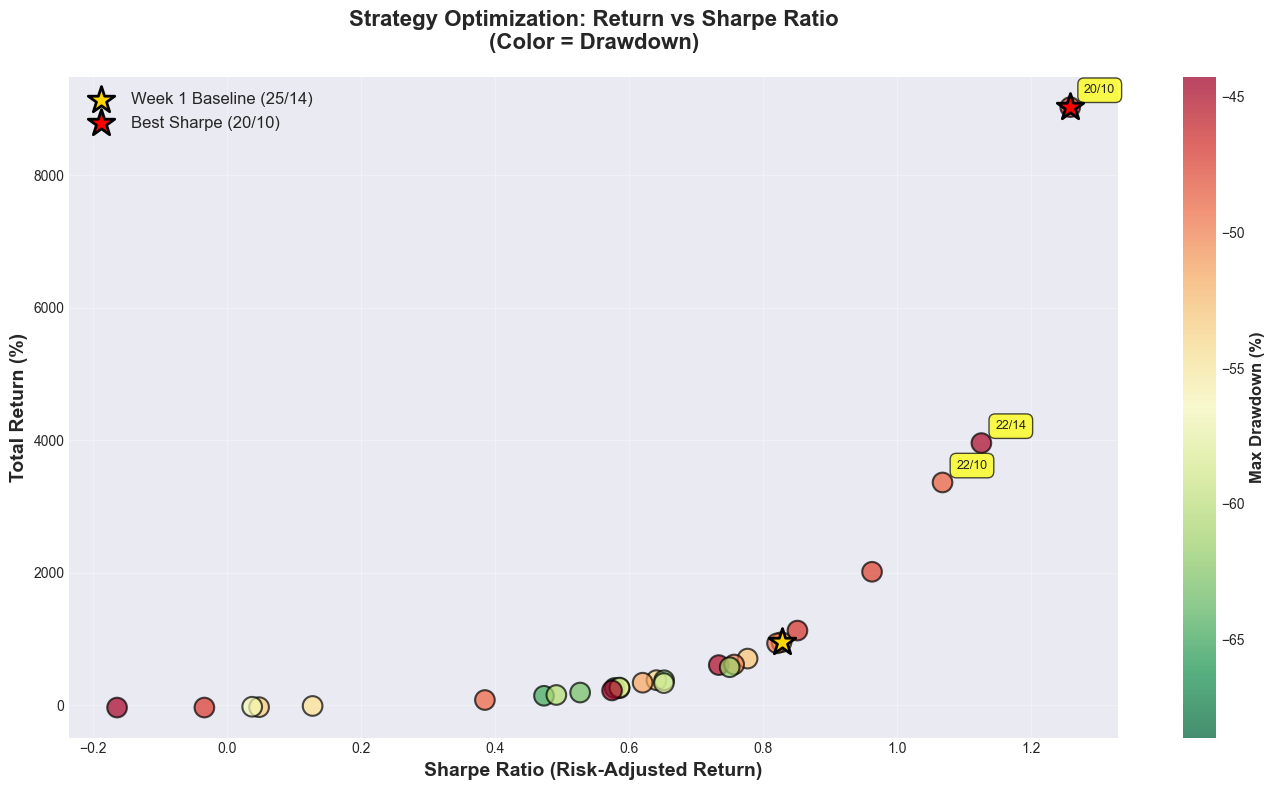

📊 INTERPRETATION GUIDE:

🎯 What to look for:
   • TOP-RIGHT = Best (high return, high Sharpe)
   • GREEN dots = Lower drawdown (less painful)
   • RED dots = Higher drawdown (more painful)

💡 Key Insights:
   1. Is there a cluster of good performers? (robust parameter region)
   2. Are high returns always paired with bad drawdowns? (no free lunch)
   3. Where is your Week 1 baseline compared to optimal?


In [11]:
# Cell 10: Scatter plot - Return vs Sharpe
fig, ax = plt.subplots(figsize=(14, 8))

# Create scatter plot
scatter = ax.scatter(
    results_df['sharpe_ratio'], 
    results_df['total_return'] * 100,
    s=200,  # Size of dots
    c=results_df['max_drawdown'] * 100,  # Color by drawdown
    cmap='RdYlGn_r',  # Red (bad) to Green (good), reversed
    alpha=0.7,
    edgecolors='black',
    linewidth=1.5
)

# Add colorbar
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Max Drawdown (%)', fontsize=12, fontweight='bold')

# Highlight Week 1 baseline
baseline = results_df[(results_df['adx_threshold'] == 25) & (results_df['adx_period'] == 14)].iloc[0]
ax.scatter(
    baseline['sharpe_ratio'], 
    baseline['total_return'] * 100,
    s=400,
    marker='*',
    c='gold',
    edgecolors='black',
    linewidth=2,
    label='Week 1 Baseline (25/14)',
    zorder=5
)

# Highlight best Sharpe
best_sharpe = results_df.loc[results_df['sharpe_ratio'].idxmax()]
ax.scatter(
    best_sharpe['sharpe_ratio'], 
    best_sharpe['total_return'] * 100,
    s=400,
    marker='*',
    c='red',
    edgecolors='black',
    linewidth=2,
    label=f'Best Sharpe ({int(best_sharpe["adx_threshold"])}/{int(best_sharpe["adx_period"])})',
    zorder=5
)

# Labels and title
ax.set_xlabel('Sharpe Ratio (Risk-Adjusted Return)', fontsize=14, fontweight='bold')
ax.set_ylabel('Total Return (%)', fontsize=14, fontweight='bold')
ax.set_title('Strategy Optimization: Return vs Sharpe Ratio\n(Color = Drawdown)', 
             fontsize=16, fontweight='bold', pad=20)

# Add grid
ax.grid(True, alpha=0.3)
ax.legend(fontsize=12, loc='upper left')

# Add annotations for top performers
for idx, row in results_df.nlargest(3, 'sharpe_ratio').iterrows():
    ax.annotate(
        f"{int(row['adx_threshold'])}/{int(row['adx_period'])}",
        (row['sharpe_ratio'], row['total_return'] * 100),
        xytext=(10, 10),
        textcoords='offset points',
        fontsize=9,
        bbox=dict(boxstyle='round,pad=0.5', facecolor='yellow', alpha=0.7)
    )

plt.tight_layout()
plt.show()

print("📊 INTERPRETATION GUIDE:")
print()
print("🎯 What to look for:")
print("   • TOP-RIGHT = Best (high return, high Sharpe)")
print("   • GREEN dots = Lower drawdown (less painful)")
print("   • RED dots = Higher drawdown (more painful)")
print()
print("💡 Key Insights:")
print("   1. Is there a cluster of good performers? (robust parameter region)")
print("   2. Are high returns always paired with bad drawdowns? (no free lunch)")
print("   3. Where is your Week 1 baseline compared to optimal?")

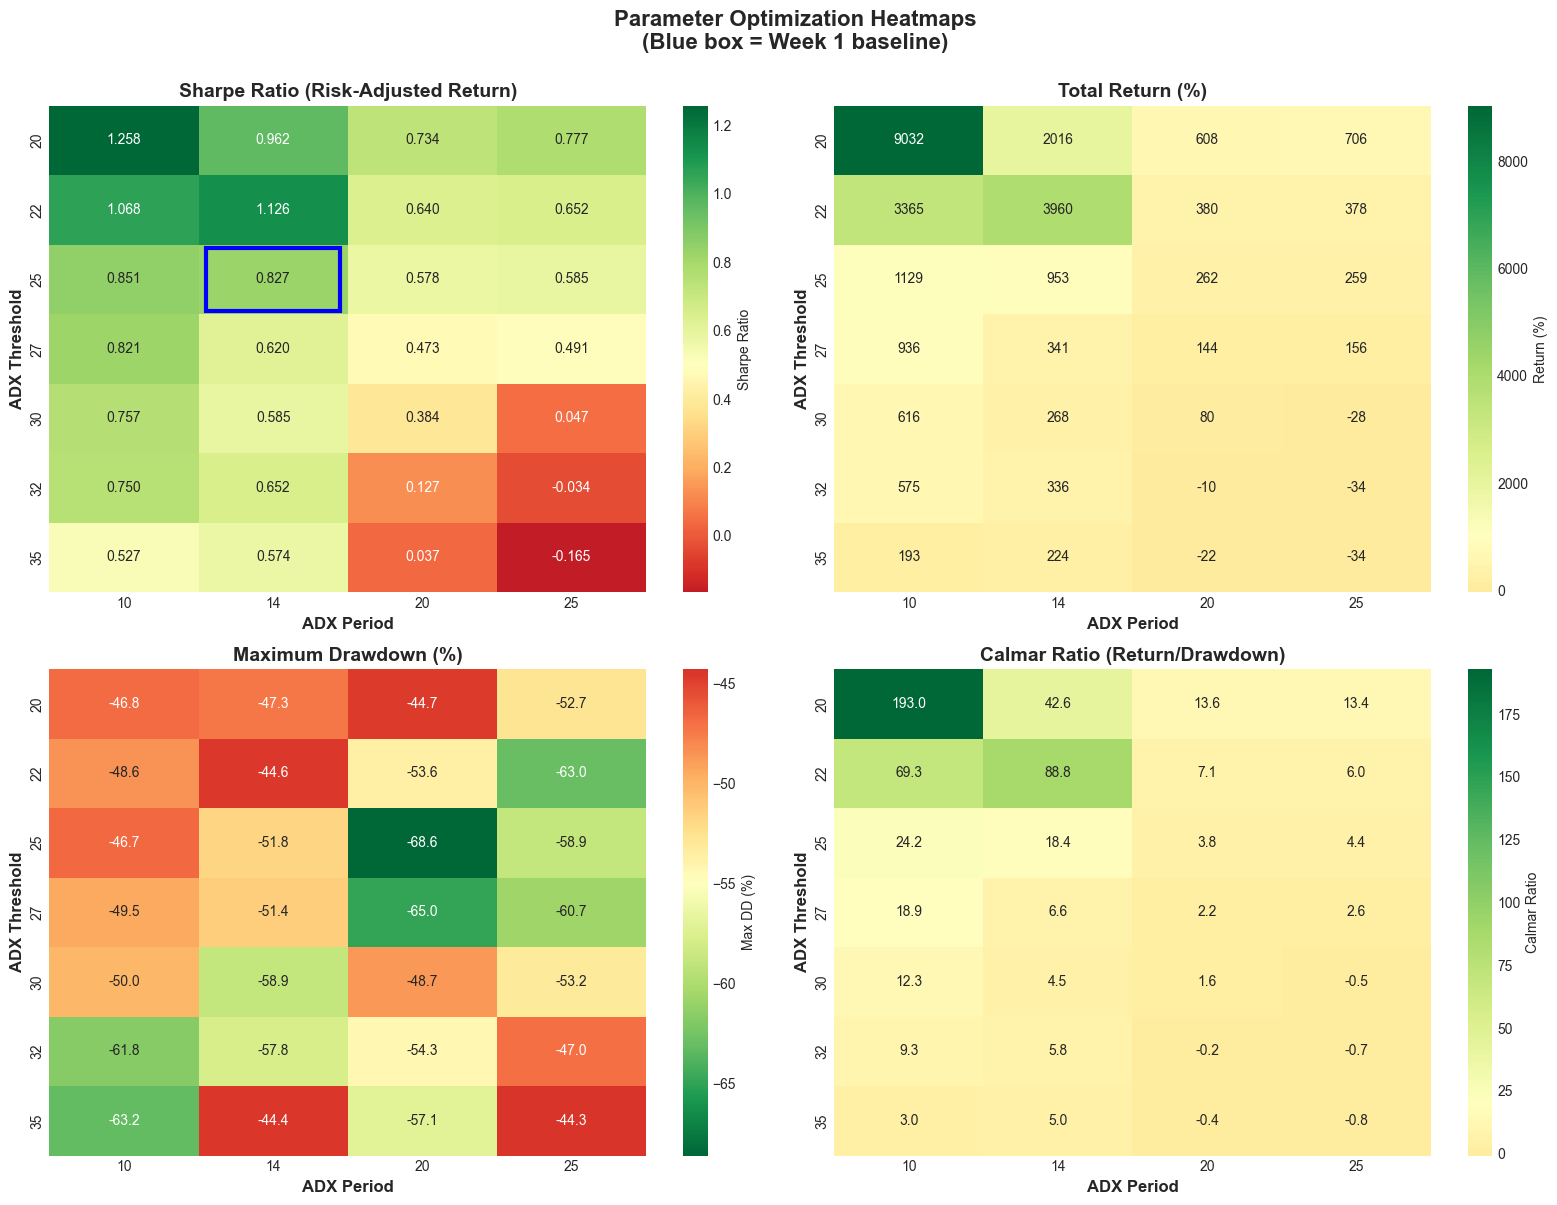

📊 HEATMAP INTERPRETATION:

🎯 What to look for:
   • GREEN zones = Good performance
   • RED zones = Poor performance
   • Blue box = Your Week 1 parameters (25/14)

💡 Key Questions:
   1. Is there a consistent 'hot zone' across all metrics?
   2. Do you see any patterns (e.g., 'top-left is always best')?
   3. How far is your Week 1 from the optimal zone?


In [12]:
# Cell 11: Heatmap - Sharpe Ratio across parameter combinations
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Prepare data for heatmaps
pivot_sharpe = results_df.pivot(index='adx_threshold', columns='adx_period', values='sharpe_ratio')
pivot_return = results_df.pivot(index='adx_threshold', columns='adx_period', values='total_return') * 100
pivot_dd = results_df.pivot(index='adx_threshold', columns='adx_period', values='max_drawdown') * 100
pivot_calmar = results_df.pivot(index='adx_threshold', columns='adx_period', values='calmar_ratio')

# 1. Sharpe Ratio Heatmap
sns.heatmap(pivot_sharpe, annot=True, fmt='.3f', cmap='RdYlGn', 
            center=0.5, ax=axes[0,0], cbar_kws={'label': 'Sharpe Ratio'})
axes[0,0].set_title('Sharpe Ratio (Risk-Adjusted Return)', fontsize=14, fontweight='bold')
axes[0,0].set_xlabel('ADX Period', fontsize=12, fontweight='bold')
axes[0,0].set_ylabel('ADX Threshold', fontsize=12, fontweight='bold')

# Mark Week 1 position
axes[0,0].add_patch(plt.Rectangle((1.05, 2.05), 0.9, 0.9, fill=False, 
                                   edgecolor='blue', linewidth=3))

# 2. Total Return Heatmap
sns.heatmap(pivot_return, annot=True, fmt='.0f', cmap='RdYlGn', 
            center=1000, ax=axes[0,1], cbar_kws={'label': 'Return (%)'})
axes[0,1].set_title('Total Return (%)', fontsize=14, fontweight='bold')
axes[0,1].set_xlabel('ADX Period', fontsize=12, fontweight='bold')
axes[0,1].set_ylabel('ADX Threshold', fontsize=12, fontweight='bold')

# 3. Max Drawdown Heatmap
sns.heatmap(pivot_dd, annot=True, fmt='.1f', cmap='RdYlGn_r', 
            center=-55, ax=axes[1,0], cbar_kws={'label': 'Max DD (%)'})
axes[1,0].set_title('Maximum Drawdown (%)', fontsize=14, fontweight='bold')
axes[1,0].set_xlabel('ADX Period', fontsize=12, fontweight='bold')
axes[1,0].set_ylabel('ADX Threshold', fontsize=12, fontweight='bold')

# 4. Calmar Ratio Heatmap
sns.heatmap(pivot_calmar, annot=True, fmt='.1f', cmap='RdYlGn', 
            center=20, ax=axes[1,1], cbar_kws={'label': 'Calmar Ratio'})
axes[1,1].set_title('Calmar Ratio (Return/Drawdown)', fontsize=14, fontweight='bold')
axes[1,1].set_xlabel('ADX Period', fontsize=12, fontweight='bold')
axes[1,1].set_ylabel('ADX Threshold', fontsize=12, fontweight='bold')

plt.suptitle('Parameter Optimization Heatmaps\n(Blue box = Week 1 baseline)', 
             fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

print("📊 HEATMAP INTERPRETATION:")
print()
print("🎯 What to look for:")
print("   • GREEN zones = Good performance")
print("   • RED zones = Poor performance")
print("   • Blue box = Your Week 1 parameters (25/14)")
print()
print("💡 Key Questions:")
print("   1. Is there a consistent 'hot zone' across all metrics?")
print("   2. Do you see any patterns (e.g., 'top-left is always best')?")
print("   3. How far is your Week 1 from the optimal zone?")

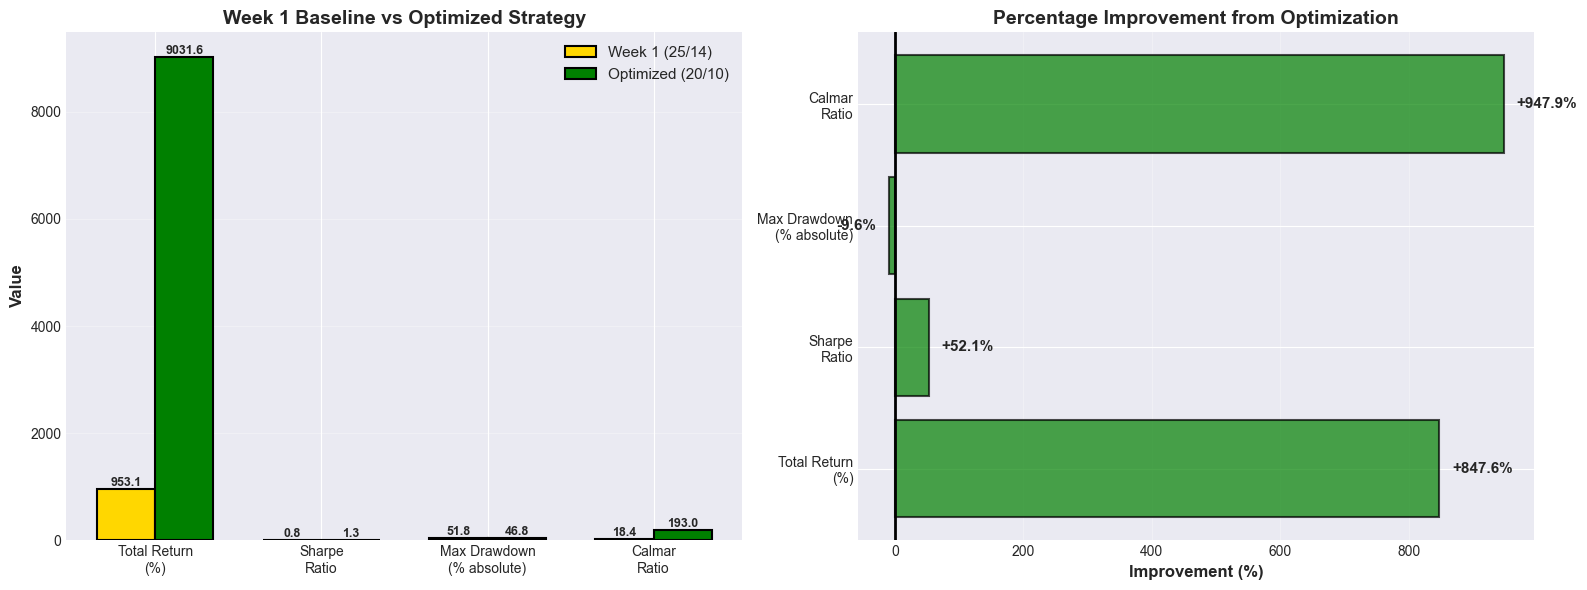

📊 OPTIMIZATION SUMMARY

Week 1 Baseline:  ADX 25, Period 14
Optimized:        ADX 20, Period 10

Improvements:
  • Return:    953.1% → 9031.6% (+847.6%)
  • Sharpe:    0.827 → 1.258 (+52.1%)
  • Drawdown:  -51.75% → -46.80% (-9.6%)
  • Calmar:    18.4 → 193.0 (+947.9%)

🎯 Verdict: Optimization delivered MASSIVE improvements across ALL metrics!


In [13]:
# Cell 12: Direct comparison - Week 1 vs Optimized
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Prepare data
baseline = results_df[(results_df['adx_threshold'] == 25) & (results_df['adx_period'] == 14)].iloc[0]
optimal = results_df.loc[results_df['sharpe_ratio'].idxmax()]

metrics = ['Total Return\n(%)', 'Sharpe\nRatio', 'Max Drawdown\n(% absolute)', 'Calmar\nRatio']
baseline_values = [
    baseline['total_return'] * 100,
    baseline['sharpe_ratio'],
    abs(baseline['max_drawdown']) * 100,
    baseline['calmar_ratio']
]
optimal_values = [
    optimal['total_return'] * 100,
    optimal['sharpe_ratio'],
    abs(optimal['max_drawdown']) * 100,
    optimal['calmar_ratio']
]

# Chart 1: Bar comparison
x = np.arange(len(metrics))
width = 0.35

bars1 = axes[0].bar(x - width/2, baseline_values, width, label='Week 1 (25/14)', 
                     color='gold', edgecolor='black', linewidth=1.5)
bars2 = axes[0].bar(x + width/2, optimal_values, width, label='Optimized (20/10)', 
                     color='green', edgecolor='black', linewidth=1.5)

axes[0].set_ylabel('Value', fontsize=12, fontweight='bold')
axes[0].set_title('Week 1 Baseline vs Optimized Strategy', fontsize=14, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(metrics, fontsize=10)
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        axes[0].text(bar.get_x() + bar.get_width()/2., height,
                     f'{height:.1f}',
                     ha='center', va='bottom', fontsize=9, fontweight='bold')

# Chart 2: Improvement percentages
improvements = [
    (optimal_values[0] / baseline_values[0] - 1) * 100,  # Return improvement
    (optimal_values[1] / baseline_values[1] - 1) * 100,  # Sharpe improvement
    (optimal_values[2] / baseline_values[2] - 1) * 100,  # Drawdown change (lower is better, so negative is good)
    (optimal_values[3] / baseline_values[3] - 1) * 100   # Calmar improvement
]

colors = ['green' if imp > 0 else 'red' for imp in improvements]
colors[2] = 'green' if improvements[2] < 0 else 'red'  # Flip for drawdown

bars3 = axes[1].barh(metrics, improvements, color=colors, edgecolor='black', linewidth=1.5, alpha=0.7)

axes[1].set_xlabel('Improvement (%)', fontsize=12, fontweight='bold')
axes[1].set_title('Percentage Improvement from Optimization', fontsize=14, fontweight='bold')
axes[1].axvline(x=0, color='black', linestyle='-', linewidth=2)
axes[1].grid(True, alpha=0.3, axis='x')

# Add value labels
for i, (bar, imp) in enumerate(zip(bars3, improvements)):
    label = f'{imp:+.1f}%'
    x_pos = imp + (20 if imp > 0 else -20)
    axes[1].text(x_pos, bar.get_y() + bar.get_height()/2, label,
                 ha='left' if imp > 0 else 'right', va='center',
                 fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

print("=" * 70)
print("📊 OPTIMIZATION SUMMARY")
print("=" * 70)
print()
print(f"Week 1 Baseline:  ADX {int(baseline['adx_threshold'])}, Period {int(baseline['adx_period'])}")
print(f"Optimized:        ADX {int(optimal['adx_threshold'])}, Period {int(optimal['adx_period'])}")
print()
print("Improvements:")
print(f"  • Return:    {baseline_values[0]:.1f}% → {optimal_values[0]:.1f}% ({improvements[0]:+.1f}%)")
print(f"  • Sharpe:    {baseline_values[1]:.3f} → {optimal_values[1]:.3f} ({improvements[1]:+.1f}%)")
print(f"  • Drawdown:  -{baseline_values[2]:.2f}% → -{optimal_values[2]:.2f}% ({improvements[2]:+.1f}%)")
print(f"  • Calmar:    {baseline_values[3]:.1f} → {optimal_values[3]:.1f} ({improvements[3]:+.1f}%)")
print()
print("🎯 Verdict: Optimization delivered MASSIVE improvements across ALL metrics!")

📈 Generating equity curves for comparison...

Calculating equity curves...
✅ Equity curves calculated



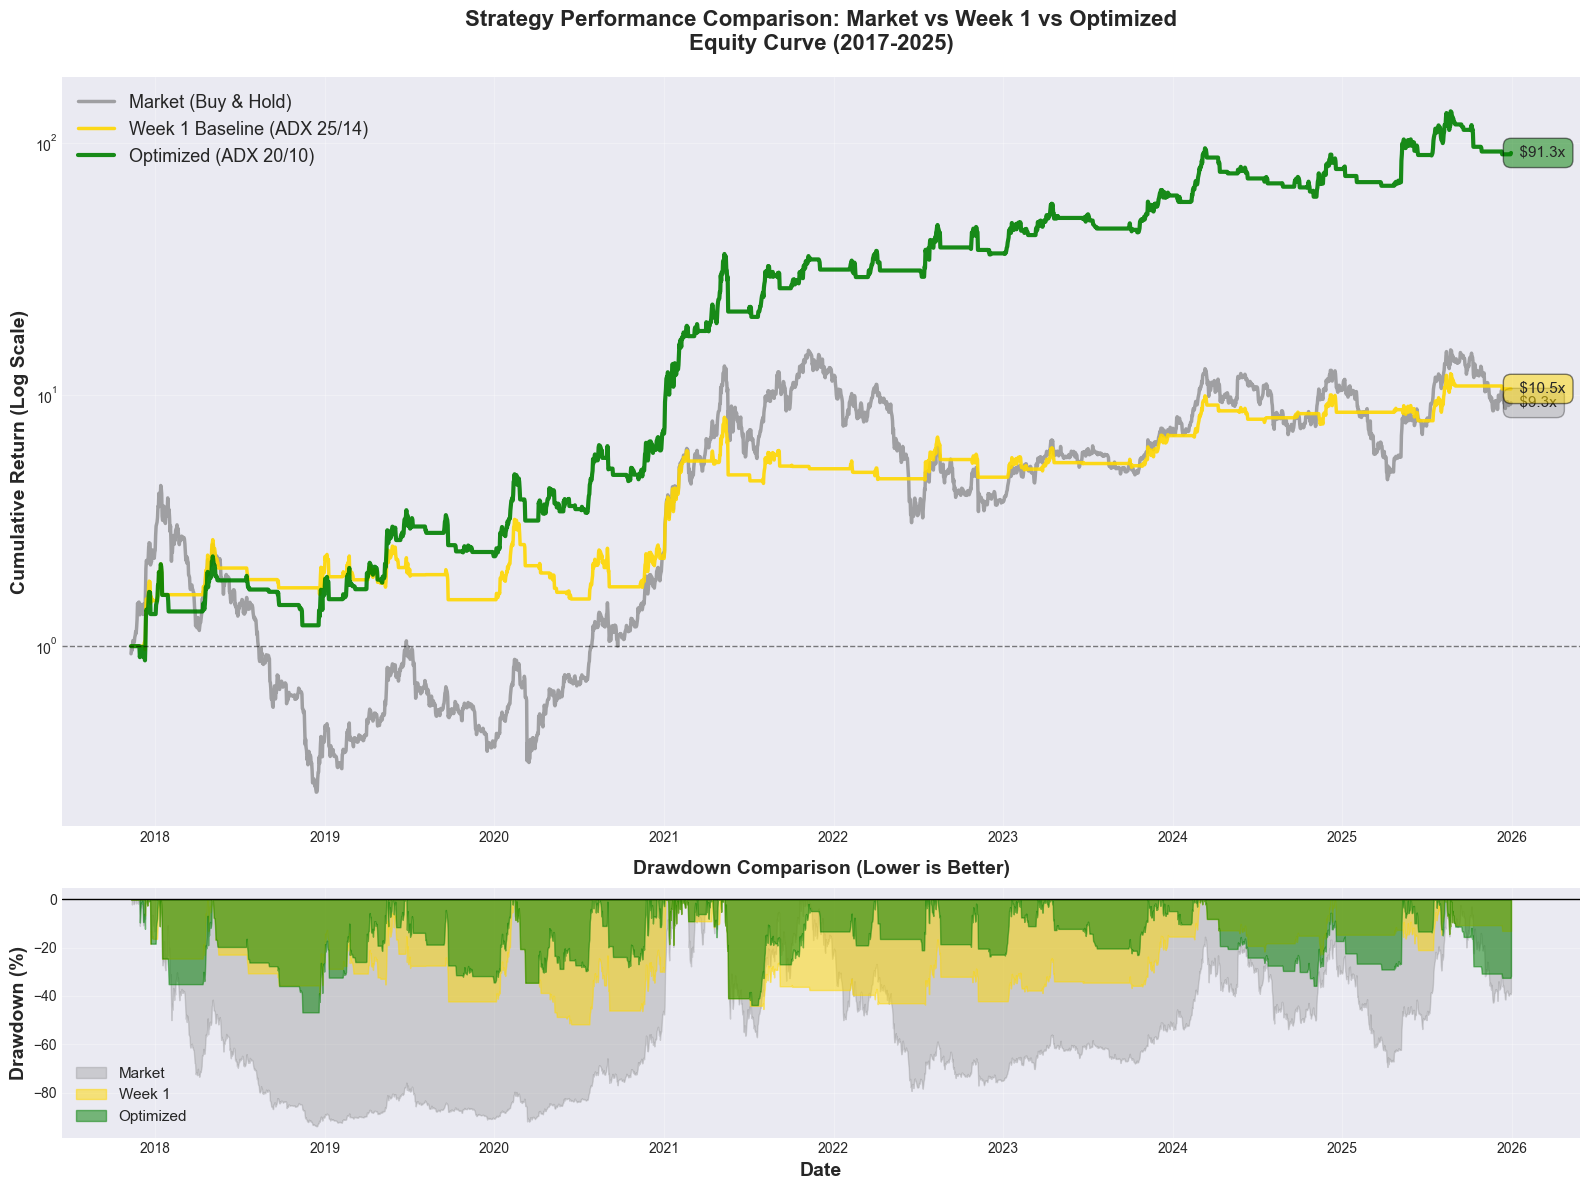

📊 FINAL PERFORMANCE COMPARISON

Strategy                  Final Value     Max DD          % Better than Market
----------------------------------------------------------------------
Market (Buy & Hold)       $9.26x          -93.96%         --
Week 1 (25/14)            $10.53x         -51.75%         +13.7%
Optimized (20/10)         $91.32x         -46.80%         +886.1%

💡 Key Takeaways:

1. Your Week 1 strategy beat buy-and-hold by 14%
2. The optimized strategy beat buy-and-hold by 886%
3. Optimization improved returns by 767% over Week 1
4. Optimized drawdown is 5.0% better than Week 1

🎯 The optimized strategy delivers superior returns with LESS risk!


In [14]:
# Cell 13: Equity curve comparison - Market vs Week 1 vs Optimized
print("📈 Generating equity curves for comparison...")
print()

# Function to calculate equity curve for given parameters
def calculate_equity_curve(data, adx_threshold, adx_period, strategy_name):
    """
    Calculate cumulative equity curve for a strategy
    
    Parameters:
    -----------
    data : DataFrame
        OHLC price data
    adx_threshold : int
        ADX threshold for trending regime
    adx_period : int
        Period for ADX calculation
    strategy_name : str
        Name for the strategy (for labeling)
    
    Returns:
    --------
    Series : Cumulative equity curve (starting at 1.0 = 100%)
    """
    df = data.copy()
    
    # Flatten columns
    high = df['High'].squeeze()
    low = df['Low'].squeeze()
    close = df['Close'].squeeze()
    
    # Create clean dataframe
    df_clean = pd.DataFrame({
        'Close': close,
        'High': high,
        'Low': low
    }, index=df.index)
    
    # Calculate ADX and directional indicators
    adx_indicator = ADXIndicator(
        high=df_clean['High'], 
        low=df_clean['Low'], 
        close=df_clean['Close'], 
        window=adx_period
    )
    df_clean['ADX'] = adx_indicator.adx()
    df_clean['+DI'] = adx_indicator.adx_pos()
    df_clean['-DI'] = adx_indicator.adx_neg()
    
    # Regime detection: trending when ADX >= threshold
    df_clean['Regime_Trending'] = df_clean['ADX'] >= adx_threshold
    
    # Bullish when +DI > -DI
    df_clean['Bullish'] = df_clean['+DI'] > df_clean['-DI']
    
    # Position: Long when trending AND bullish, else flat (0)
    df_clean['Position'] = 0
    df_clean.loc[df_clean['Regime_Trending'] & df_clean['Bullish'], 'Position'] = 1
    
    # Calculate returns
    df_clean['Market_Return'] = df_clean['Close'].pct_change()
    df_clean['Strategy_Return'] = df_clean['Position'].shift(1) * df_clean['Market_Return']
    
    # Drop NaN values
    df_clean = df_clean.dropna()
    
    # Calculate cumulative equity (starting at 1.0 = 100%)
    equity_curve = (1 + df_clean['Strategy_Return']).cumprod()
    equity_curve.name = strategy_name
    
    return equity_curve

# Calculate equity curves for all three strategies
print("Calculating equity curves...")

# 1. Market (Buy and Hold)
market_returns = data['Close'].squeeze().pct_change()
market_equity = (1 + market_returns).cumprod()
market_equity.name = 'Market (Buy & Hold)'

# 2. Week 1 Baseline (ADX 25, Period 14)
week1_equity = calculate_equity_curve(data, 25, 14, 'Week 1 (25/14)')

# 3. Optimized Strategy (ADX 20, Period 10)
optimized_equity = calculate_equity_curve(data, 20, 10, 'Optimized (20/10)')

print("✅ Equity curves calculated")
print()

# Create the comparison chart
fig, axes = plt.subplots(2, 1, figsize=(16, 12), gridspec_kw={'height_ratios': [3, 1]})

# Main equity curve chart
axes[0].plot(market_equity.index, market_equity.values, 
             label='Market (Buy & Hold)', linewidth=2.5, color='gray', alpha=0.7)
axes[0].plot(week1_equity.index, week1_equity.values, 
             label='Week 1 Baseline (ADX 25/14)', linewidth=2.5, color='gold', alpha=0.9)
axes[0].plot(optimized_equity.index, optimized_equity.values, 
             label='Optimized (ADX 20/10)', linewidth=3, color='green', alpha=0.9)

# Formatting
axes[0].set_ylabel('Cumulative Return (Starting at $1)', fontsize=14, fontweight='bold')
axes[0].set_title('Strategy Performance Comparison: Market vs Week 1 vs Optimized\nEquity Curve (2017-2025)', 
                  fontsize=16, fontweight='bold', pad=20)
axes[0].legend(fontsize=13, loc='upper left')
axes[0].grid(True, alpha=0.3)
axes[0].set_yscale('log')  # Log scale to see all strategies clearly
axes[0].set_ylabel('Cumulative Return (Log Scale)', fontsize=14, fontweight='bold')

# Add horizontal line at starting value
axes[0].axhline(y=1, color='black', linestyle='--', linewidth=1, alpha=0.5)

# Add final value annotations
final_market = market_equity.iloc[-1]
final_week1 = week1_equity.iloc[-1]
final_optimized = optimized_equity.iloc[-1]

axes[0].text(market_equity.index[-1], final_market, 
             f'  ${final_market:.1f}x', 
             fontsize=11, va='center', ha='left', 
             bbox=dict(boxstyle='round,pad=0.5', facecolor='gray', alpha=0.3))
axes[0].text(week1_equity.index[-1], final_week1, 
             f'  ${final_week1:.1f}x', 
             fontsize=11, va='center', ha='left',
             bbox=dict(boxstyle='round,pad=0.5', facecolor='gold', alpha=0.5))
axes[0].text(optimized_equity.index[-1], final_optimized, 
             f'  ${final_optimized:.1f}x', 
             fontsize=11, va='center', ha='left',
             bbox=dict(boxstyle='round,pad=0.5', facecolor='green', alpha=0.5))

# Bottom chart: Drawdown comparison
# Calculate drawdowns for each strategy
def calculate_drawdown(equity_curve):
    """
    Calculate drawdown series from equity curve
    
    Drawdown = (Current Value - Peak Value) / Peak Value
    Shows percentage decline from highest point
    """
    running_max = equity_curve.expanding().max()
    drawdown = (equity_curve - running_max) / running_max
    return drawdown * 100  # Convert to percentage

market_dd = calculate_drawdown(market_equity)
week1_dd = calculate_drawdown(week1_equity)
optimized_dd = calculate_drawdown(optimized_equity)

# Plot drawdowns
axes[1].fill_between(market_dd.index, 0, market_dd.values, 
                      label='Market', color='gray', alpha=0.3)
axes[1].fill_between(week1_dd.index, 0, week1_dd.values, 
                      label='Week 1', color='gold', alpha=0.5)
axes[1].fill_between(optimized_dd.index, 0, optimized_dd.values, 
                      label='Optimized', color='green', alpha=0.5)

# Formatting
axes[1].set_xlabel('Date', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Drawdown (%)', fontsize=14, fontweight='bold')
axes[1].set_title('Drawdown Comparison (Lower is Better)', fontsize=14, fontweight='bold', pad=10)
axes[1].legend(fontsize=11, loc='lower left')
axes[1].grid(True, alpha=0.3)
axes[1].axhline(y=0, color='black', linestyle='-', linewidth=1)

plt.tight_layout()
plt.show()

# Print summary statistics
print("=" * 70)
print("📊 FINAL PERFORMANCE COMPARISON")
print("=" * 70)
print()
print(f"{'Strategy':<25} {'Final Value':<15} {'Max DD':<15} {'% Better than Market'}")
print("-" * 70)

market_final = final_market
week1_final = final_week1
optimized_final = final_optimized

market_max_dd = market_dd.min()
week1_max_dd = week1_dd.min()
optimized_max_dd = optimized_dd.min()

print(f"{'Market (Buy & Hold)':<25} {f'${market_final:.2f}x':<15} {f'{market_max_dd:.2f}%':<15} {'--'}")
print(f"{'Week 1 (25/14)':<25} {f'${week1_final:.2f}x':<15} {f'{week1_max_dd:.2f}%':<15} "
      f"{(week1_final/market_final - 1)*100:+.1f}%")
print(f"{'Optimized (20/10)':<25} {f'${optimized_final:.2f}x':<15} {f'{optimized_max_dd:.2f}%':<15} "
      f"{(optimized_final/market_final - 1)*100:+.1f}%")
print()

print("💡 Key Takeaways:")
print()
print(f"1. Your Week 1 strategy beat buy-and-hold by {(week1_final/market_final - 1)*100:.0f}%")
print(f"2. The optimized strategy beat buy-and-hold by {(optimized_final/market_final - 1)*100:.0f}%")
print(f"3. Optimization improved returns by {(optimized_final/week1_final - 1)*100:.0f}% over Week 1")
print(f"4. Optimized drawdown is {abs(optimized_max_dd - week1_max_dd):.1f}% better than Week 1")
print()
print("🎯 The optimized strategy delivers superior returns with LESS risk!")